In [5]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/optimal-control-notes-code/code/with-notes/exercise-2`
    Updating registry at `~/.julia/registries/General.toml`
┌ Error: Some registries failed to update:
│     — /home/xwc/.julia/registries/General.toml — failed to download from https://mirrors.cernet.edu.cn/julia/registry/23338594-aafe-5451-b93e-139f81909106/9dc1a55f300a6a9bf7cd9b7c2cded1829a578ff4. Exception: RequestError: HTTP/2 200 (Failed receiving HTTP2 data) while requesting https://mirrors.cernet.edu.cn/julia/registry/23338594-aafe-5451-b93e-139f81909106/9dc1a55f300a6a9bf7cd9b7c2cded1829a578ff4
└ @ Pkg.Registry ~/julia-1.9.2/share/julia/stdlib/v1.9/Pkg/src/Registry/Registry.jl:510
    Updating `~/optimal-control-notes-code/code/with-notes/exercise-2/Project.toml`
  [f65535da] + Convex v0.15.3
  [e2685f51] + ECOS v1.1.1
  [f6369f11] + ForwardDiff v0.10.36
  [b8b539d8] + JupyterFormatter v0.1.0
  [b964fa9f] + LaTeXStrings v1.3.0
  [91a5bcdd] + Plots v1.38.17
  [d330b81b] + PyPlot v2.11.2
    Updatin

In [27]:
using LaTeXStrings;
using Plots;
pyplot();
PyPlot.matplotlib.rc("text", usetex = true);
PyPlot.matplotlib.rc("font", family = "Times New Roman");
PyPlot.matplotlib.rc("text.latex", preamble = "\\usepackage{{amsmath}}");

using JupyterFormatter;
whitespace_in_kwargs = false;
format_docstrings = true
enable_autoformat();

In [7]:
using LinearAlgebra, Plots;
import ForwardDiff as FD;
using Test;
import Convex as cvx;
import ECOS;
using Random;

## Julia Warnings:

1. For a function `foo(x::Vector)` with 1 input argument, it is not neccessary to do `df_dx = FD.jacobian(_x -> foo(_x), x)`. Instead you can just do `df_dx = FD.jacobian(foo, x)`. If you do the first one, it can dramatically slow down your compliation time. 

2. Do not define functions inside of other functions like this:
```julia
function foo(x)
    # main function foo 
    
    function body(x)
        # function inside function (DON'T DO THIS)
        return 2*x 
    end
    
    return body(x)
end
```
This will also slow down your compilation time dramatically.

# Q1: Finite-Horizon LQR
For this problem we are going to consider a "double integrator" for our dynamics model. This system has a state $x \in \mathbb{R}^4$, and control $u \in \mathbb{R}^2$, where the state describes the 2D position $p$ and velocity $v$ of an object, and the control is the acceleration $a$ of this object.  The state and control are the following:
$$\begin{align} x &= [p_1, p_2, v_1, v_2] \\ u &= [a_1, a_2] \end{align}$$
And the continuous time dynamics for this system are the following:
$$\begin{align} \dot{x} =  \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{bmatrix} x + \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \end{align} u$$

In [8]:
# double integrator dynamics 
function double_integrator_AB(dt)::Tuple{Matrix,Matrix}
    Ac = [
        0 0 1 0
        0 0 0 1
        0 0 0 0
        0 0 0 0.0
    ]
    Bc = [
        0 0
        0 0
        1 0
        0 1
    ]
    nx, nu = size(Bc)

    # matrix exponential 
    H = exp([Ac Bc; zeros(nu, nx + nu)] * dt)
    A = H[1:nx, 1:nx]
    B = H[1:nx, (nx+1):(nx+nu)]

    return A, B
end;

In [29]:
@testset "discrete time dynamics" begin
    dt = 0.1
    A, B = double_integrator_AB(dt)

    x = [1, 2, 3, 4.0]
    u = [-1, -3.0]

    @test isapprox((A * x + B * u), [1.295, 2.385, 2.9, 3.7]; atol = 1e-10)

end;

Test Summary:          | Pass  Total  Time
discrete time dynamics |    1      1  0.0s


## Part (A): Finite Horizon LQR via Convex Optimization

We are now going to solve the finite horizon LQR problem with convex optimization. As we went over in class, this problem requires $Q \in S_+$(Q is symmetric positive semi-definite) and $R \in S_{++}$ (R is symmetric positive definite).  With this, the optimization problem can be stated as the following:
$$ \begin{align} \min_{x_{1:N},u_{1:N-1}} \quad & \sum_{i=1}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st} \quad & x_1 = x_{\text{IC}} \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = 1,2,\ldots,N-1 
 \end{align}$$
This problem is a convex optimization problem since the cost function is a convex quadratic and the constraints are all linear equality constraints. We will setup and solve this exact problem using the `Convex.jl` modeling package. We will fill out a function `Xcvx,Ucvx = convex_trajopt(A,B,Q,R,Qf,N,x_ic)`, where we will form and solve the above optimization problem. 

In [10]:
# utilities for converting to and from vector of vectors <-> matrix
function mat_from_vec(X::Vector{Vector{Float64}})::Matrix
    # convert a vector of vector to a matrix
    # return hcat(X...)
    return reduce(hcat, X)  # more efficient
end;

In [11]:
function vec_from_mat(Xm::Matrix)::Vector{Vector{Float64}}
    # convert a matrix to a vector of vector
    return [x for x in eachcol(Xm)]
end;

In [28]:
function convex_trajopt(
    A::Matrix,# A matrix 
    B::Matrix,# B matrix 
    Q::Matrix,# cost weight 
    R::Matrix,# cost weight 
    Qf::Matrix, # terminal cost weight 
    N::Int64, # horizon size 
    x_ic::Vector; # initial condition
    verbose = false,
)::Tuple{Vector{Vector{Float64}},Vector{Vector{Float64}}}
    # check size of everything
    nx, nu = size(B)
    @assert size(A) == (nx, nx)
    @assert size(Q) == (nx, nx)
    @assert size(R) == (nu, nu)
    @assert size(Qf) == (nx, nx)
    @assert length(x_ic) == nx

    # create cvx variable
    X = cvx.Variable(nx, N)
    U = cvx.Variable(nu, N - 1)

    # create cost
    cost = 0
    for k = 1:(N-1)
        cost += 0.5 * cvx.quadform(X[:, k], Q) + 0.5 * cvx.quadform(U[:, k], R)
    end
    cost += 0.5 * cvx.quadform(X[:, N], Qf)

    # initialize cvx problem
    prob = cvx.minimize(cost)

    # initial condition constraint
    prob.constraints += (X[:, 1] == x_ic)

    for k = 1:(N-1)
        # dynamic constraints
        prob.constraints += (X[:, k+1] == A * X[:, k] + B * U[:, k])
    end

    # solve problem (silent solver tells us the output)
    cvx.solve!(prob, ECOS.Optimizer; silent_solver = !verbose)

    if prob.status != cvx.MathOptInterface.OPTIMAL
        error("Convex.jl problem failed to solve for some reason")
    end

    # convert the solution matrices into vectors of vectors
    X = vec_from_mat(X.value)
    U = vec_from_mat(U.value)

    return X, U
end;

Now let's solve this problem for a given initial condition, and simulate it to see how it does:

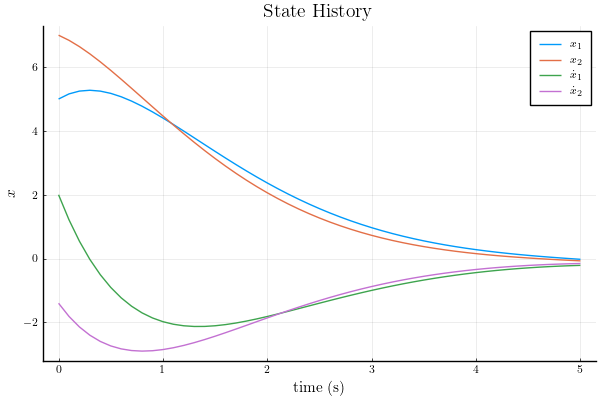

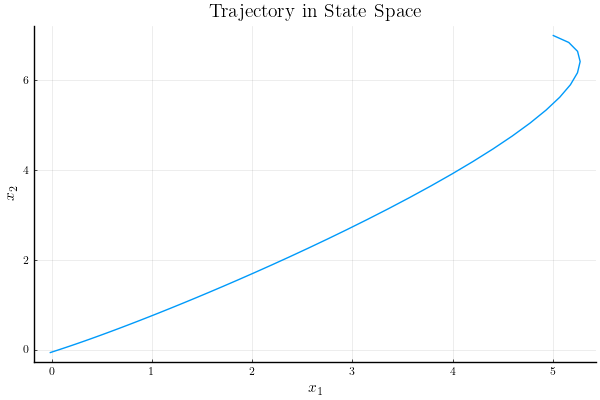

Test Summary:     | Pass  Total  Time
LQR via Convex.jl |    4      4  1.1s


In [18]:
@testset "LQR via Convex.jl" begin

    # problem setup stuff 
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    Q = diagm(ones(nx))  # do not use I()
    R = diagm(ones(nu))
    Qf = 5 * Q

    # initial condition 
    x_ic = [5, 7, 2, -1.4]

    # setup and solve our convex optimization problem (verbose = true for submission)
    Xcvx, Ucvx = convex_trajopt(A, B, Q, R, Qf, N, x_ic; verbose = false)

    # now let's simulate using Ucvx on our discrete time dynamics
    Xsim = [zeros(nx) for i = 1:N]
    Xsim[1] = 1 * x_ic
    for i = 1:N-1
        Xsim[i+1] = A * Xsim[i] + B * Ucvx[i]
    end

    #----------------------plotting-----------------------
    Xsim_m = mat_from_vec(Xsim)

    # plot state history 
    display(
        plot(
            t_vec,
            Xsim_m',
            label = [L"x_1" L"x_2" L"\dot x_1" L"\dot x_2"],
            title = "State History",
            xlabel = "time (s)",
            ylabel = L"x",
        ),
    )

    # plot trajectory in x1 x2 space 
    display(
        plot(
            Xsim_m[1, :],
            Xsim_m[2, :],
            title = "Trajectory in State Space",
            ylabel = L"x_2",
            xlabel = L"x_1",
            label = "",
        ),
    )

    PyPlot.close()  # prevent redundant plots
    #----------------------plotting-----------------------

    # tests 
    @test 1e-14 < maximum(norm.(Xsim .- Xcvx, Inf)) < 1e-3
    @test isapprox(Ucvx[1], [-7.8532442316767, -4.127120137234], atol = 1e-3)
    @test isapprox(Xcvx[end], [-0.02285990, -0.07140241, -0.21259, -0.1540299], atol = 1e-3)
    @test 1e-14 < norm(Xcvx[end] - Xsim[end]) < 1e-3
end;

### Bellman's Principle of Optimality
Now we will test Bellman's Principle of optimality. This can be phrased in many different ways, but the main gist is that any section of an optimal trajectory must be optimal. Our original optimization problem was the above problem:
$$ \begin{align} \min_{x_{1:N},u_{1:N-1}} \quad & \sum_{i=1}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st} \quad & x_1 = x_{\text{IC}} \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = 1,2,\ldots,N-1 
 \end{align}$$
which has a solution $x^*_{1:N},u^*_{1:N-1}$. Now let's look at optimizing over a subsection of this trajectory. That means that instead of solving for $x_{1:N},u_{1:N-1}$, we are now solving for $x_{L:N},u_{L:N-1}$ for some new timestep $1 < L < N$. What we are going to do is take the initial condition from $x^*_L$ from our original optimization problem, and setup a new optimization problem that optimizes over $x_{L:N},u_{L:N-1}$:
$$ \begin{align} \min_{x_{L:N},u_{L:N-1}} \quad & \sum_{i=L}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st     } \quad & x_L = x^*_L \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = L,L + 1,\ldots,N-1 
 \end{align}$$

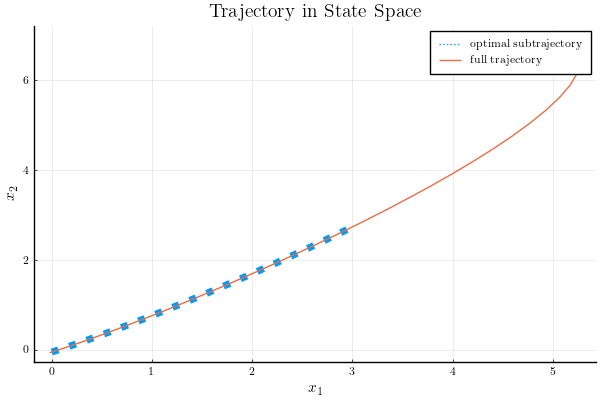

Test Summary:                     | Pass  Total  Time
Bellman's Principle of Optimality |    4      4  0.5s


Test.DefaultTestSet("Bellman's Principle of Optimality", Any[], 4, false, false, true, 1.692947322726206e9, 1.692947323252391e9, false)

In [19]:
@testset "Bellman's Principle of Optimality" begin

    # problem setup 
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    x0 = [5, 7, 2, -1.4] # initial condition 
    Q = diagm(ones(nx))
    R = diagm(ones(nu))
    Qf = 5 * Q

    # solve for X_{1:N}, U_{1:N-1} with convex optimization
    Xcvx1, Ucvx1 = convex_trajopt(A, B, Q, R, Qf, N, x0; verbose = false)

    # now let's solve a subsection of this trajectory 
    L = 18
    N_2 = N - L + 1

    # here is our updated initial condition from the first problem 
    x0_2 = Xcvx1[L]
    Xcvx2, Ucvx2 = convex_trajopt(A, B, Q, R, Qf, N_2, x0_2; verbose = false)

    # test if these trajectories match for the times they share 
    U_error = Ucvx1[L:end] .- Ucvx2
    X_error = Xcvx1[L:end] .- Xcvx2
    @test 1e-14 < maximum(norm.(U_error)) < 1e-3
    @test 1e-14 < maximum(norm.(X_error)) < 1e-3


    # ---------------------------plotting ------------------------------
    X1m = mat_from_vec(Xcvx1)
    X2m = mat_from_vec(Xcvx2)
    plot(X2m[1, :], X2m[2, :], label = "optimal subtrajectory", lw = 5, ls = :dot)
    display(
        plot!(
            X1m[1, :],
            X1m[2, :],
            title = "Trajectory in State Space",
            ylabel = L"x_2",
            xlabel = L"x_1",
            label = "full trajectory",
        ),
    )
    PyPlot.close()
    # ---------------------------plotting ------------------------------

    @test isapprox(
        Xcvx1[end],
        [-0.02285990, -0.07140241, -0.21259, -0.1540299],
        rtol = 1e-3,
    )
    @test 1e-14 < norm(Xcvx1[end] - Xcvx2[end], Inf) < 1e-3
end

## Part (B): Finite-Horizon LQR via Ricatti 
Now we are going to solve the original finite-horizon LQR problem:
$$ \begin{align} \min_{x_{1:N},u_{1:N-1}} \quad & \sum_{i=1}^{N-1} \bigg[ \frac{1}{2} x_i^TQx_i + \frac{1}{2} u_i^TRu_i \bigg] + \frac{1}{2}x_N^TQ_fx_N\\ 
 \text{st} \quad & x_1 = x_{\text{IC}} \\ 
 & x_{i+1} = A x_i + Bu_i \quad \text{for } i = 1,2,\ldots,N-1 
 \end{align}$$
 with a Ricatti recursion instead of convex optimization. We describe our optimal cost-to-go function (aka the Value function) as the following:
 
 $$V_k(x) = \frac{1}{2}x^TP_kx$$
 
 To do the Ricatti recursion, we initialize $P_N = Q_f$, and iterate backwards from $N-1$ to $1$ with the following recursion:
 
 $$ \begin{align}
 K_k &= (R + B^TP_{k+1}B)^{-1}(B^TP_{k+1}A) \\ 
 P_k &= Q + K_k^TRK_k + (A - BK_k)^TP_{k+1}(A - BK_k)
 \end{align}$$
 Which gives us an optimal policy of the following:
 $$ u_k = -K_kx_k $$ 

In [21]:
"""
use the Ricatti recursion to calculate the cost to go quadratic matrix P and 
optimal control gain K at every time step. Return these as a vector of matrices, 
where P_k = P[k], and K_k = K[k]
"""
function fhlqr(
    A::Matrix, # A matrix 
    B::Matrix, # B matrix 
    Q::Matrix, # cost weight 
    R::Matrix, # cost weight 
    Qf::Matrix,# term cost weight 
    N::Int64,   # horizon size 
)::Tuple{Vector{Matrix{Float64}},Vector{Matrix{Float64}}} # return two matrices 

    # check sizes of everything 
    nx, nu = size(B)
    @assert size(A) == (nx, nx)
    @assert size(Q) == (nx, nx)
    @assert size(R) == (nu, nu)
    @assert size(Qf) == (nx, nx)

    # instantiate S and K 
    P = [zeros(nx, nx) for i = 1:N]
    K = [zeros(nu, nx) for i = 1:N-1]

    # initialize S[N] with Qf 
    # P[N] = deepcopy(Qf)
    P[N] .= Qf

    # Ricatti 
    for k = (N-1):(-1):1
        K[k] = (R + B' * P[k+1] * B) \ (B' * P[k+1] * A)
        P[k] = Q + K[k]' * R * K[k] + (A - B * K[k])'P[k+1] * (A - B * K[k])
    end

    return P, K
end;

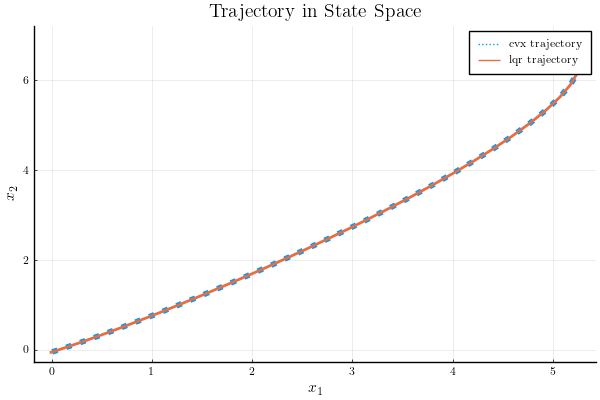

Test Summary:         | Pass  Total  Time
Convex trajopt vs LQR |    3      3  0.5s


In [24]:
@testset "Convex trajopt vs LQR" begin

    # problem stuff
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    x0 = [5, 7, 2, -1.4] # initial condition 
    Q = diagm(ones(nx))
    R = diagm(ones(nu))
    Qf = 5 * Q

    # solve for 
    Xcvx, Ucvx = convex_trajopt(A, B, Q, R, Qf, N, x0; verbose = false)
    P, K = fhlqr(A, B, Q, R, Qf, N)
    # now let's simulate using Ucvx 
    Xsim_cvx = [zeros(nx) for i = 1:N]
    Xsim_cvx[1] = 1 * x0
    Xsim_lqr = [zeros(nx) for i = 1:N]
    Xsim_lqr[1] = 1 * x0
    for i = 1:N-1
        # simulate cvx control 
        Xsim_cvx[i+1] = A * Xsim_cvx[i] + B * Ucvx[i]

        u_lqr = -K[i] * Xsim_lqr[i]
        Xsim_lqr[i+1] = A * Xsim_lqr[i] + B * u_lqr
    end


    @test isapprox(
        Xsim_lqr[end],
        [-0.02286201, -0.0714058, -0.21259, -0.154030],
        rtol = 1e-3,
    )
    @test 1e-13 < norm(Xsim_lqr[end] - Xsim_cvx[end]) < 1e-3
    @test 1e-13 < maximum(norm.(Xsim_lqr - Xsim_cvx)) < 1e-3


    # ------------------------plotting--------------------------
    X1m = mat_from_vec(Xsim_cvx)
    X2m = mat_from_vec(Xsim_lqr)
    # plot trajectory in x1 x2 space 
    plot(X2m[1, :], X2m[2, :], label = "cvx trajectory", lw = 4, ls = :dot)
    display(
        plot!(
            X1m[1, :],
            X1m[2, :],
            title = "Trajectory in State Space",
            ylabel = L"x_2",
            xlabel = L"x_1",
            lw = 2,
            label = "lqr trajectory",
        ),
    )
    PyPlot.close()
    # ------------------------plotting--------------------------

end;

To emphasize that these two methods for solving the optimization problem result in the same solutions, we are now going to sample initial conditions and run both solutions. 

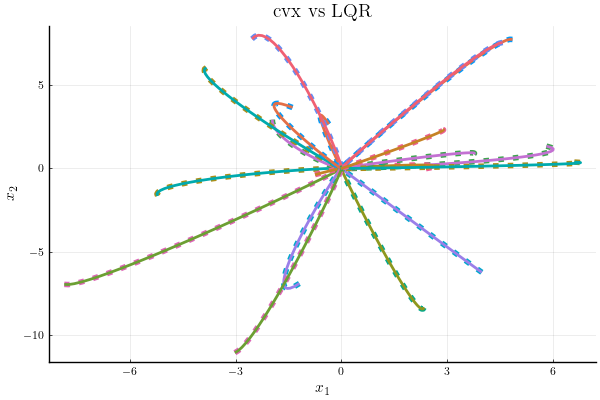

Test Summary:         | Pass  Total  Time
Convex trajopt vs LQR |   40     40  1.1s


In [31]:
import Random
Random.seed!(1)
@testset "Convex trajopt vs LQR" begin

    # problem stuff
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    Q = diagm(ones(nx))
    R = diagm(ones(nu))
    Qf = 5 * Q


    plot()
    for ic_iter = 1:20
        x0 = [5 * randn(2); 1 * randn(2)]
        Xcvx, Ucvx = convex_trajopt(A, B, Q, R, Qf, N, x0; verbose = false)
        P, K = fhlqr(A, B, Q, R, Qf, N)
        Xsim_cvx = [zeros(nx) for i = 1:N]
        Xsim_cvx[1] = 1 * x0
        Xsim_lqr = [zeros(nx) for i = 1:N]
        Xsim_lqr[1] = 1 * x0
        for i = 1:N-1
            # simulate cvx control 
            Xsim_cvx[i+1] = A * Xsim_cvx[i] + B * Ucvx[i]

            # TODO: use your FHLQR control gains K to calculate u_lqr
            # simulate lqr control 
            u_lqr = -K[i] * Xsim_lqr[i]
            Xsim_lqr[i+1] = A * Xsim_lqr[i] + B * u_lqr
        end

        @test 1e-13 < norm(Xsim_lqr[end] - Xsim_cvx[end]) < 1e-3
        @test 1e-13 < maximum(norm.(Xsim_lqr - Xsim_cvx)) < 1e-3

        # ------------------------plotting--------------------------
        X1m = mat_from_vec(Xsim_cvx)
        X2m = mat_from_vec(Xsim_lqr)
        plot!(X2m[1, :], X2m[2, :], label = "", lw = 4, ls = :dot)
        plot!(X1m[1, :], X1m[2, :], label = "", lw = 2)
    end
    display(plot!(title = "cvx vs LQR", ylabel = L"x_2", xlabel = L"x_1"))
    PyPlot.close()
end;

## Part (C): Why LQR is so great

Now we are going to emphasize two reasons why the feedback policy from LQR is so useful:

1. It is robust to noise and model uncertainty (the Convex approach would require re-solving of the problem every time the new state differs from the expected state (this is MPC, more on this in Q3)
2. We can drive to any achievable goal state with $u = -K(x - x_{goal})$

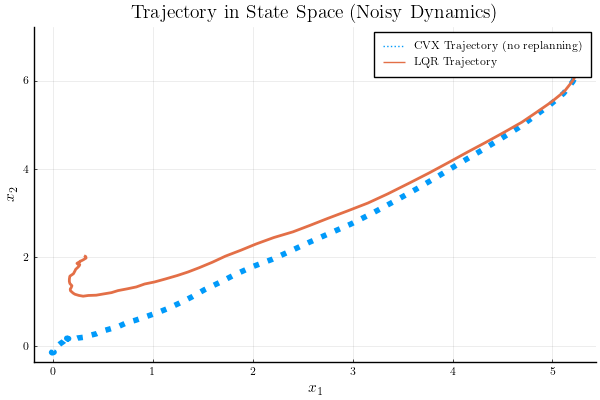

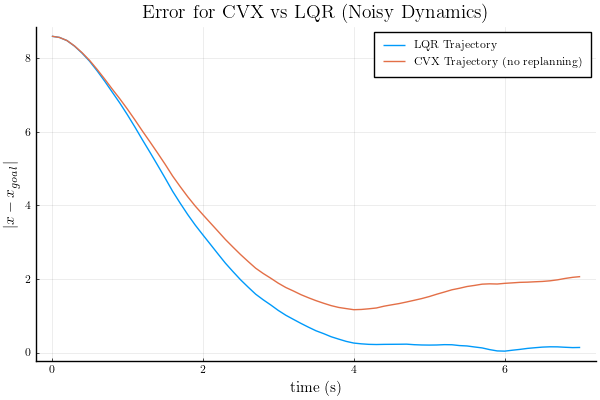

Test Summary:             |Time
Why LQR is great reason 1 | None  1.4s


In [33]:
@testset "Why LQR is great reason 1" begin

    # problem stuff
    dt = 0.1
    tf = 7.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    x0 = [5, 7, 2, -1.4] # initial condition 
    Q = diagm(ones(nx))
    R = diagm(ones(nu))
    Qf = 10 * Q

    # solve for 
    Xcvx, Ucvx = convex_trajopt(A, B, Q, R, Qf, N, x0; verbose = false)
    P, K = fhlqr(A, B, Q, R, Qf, N)
    # now let's simulate using Ucvx 
    Xsim_cvx = [zeros(nx) for i = 1:N]
    Xsim_cvx[1] = 1 * x0
    Xsim_lqr = [zeros(nx) for i = 1:N]
    Xsim_lqr[1] = 1 * x0
    for i = 1:N-1
        # sampled noise to be added after each step 
        noise = [0.005 * randn(2); 0.1 * randn(2)]

        # simulate cvx control 
        Xsim_cvx[i+1] = A * Xsim_cvx[i] + B * Ucvx[i] + noise

        u_lqr = -K[i] * Xsim_lqr[i]
        Xsim_lqr[i+1] = A * Xsim_lqr[i] + B * u_lqr + noise
    end


    # ------------------------plotting--------------------------
    X1m = mat_from_vec(Xsim_cvx)
    X2m = mat_from_vec(Xsim_lqr)
    # plot trajectory in x1 x2 space 
    plot(X2m[1, :], X2m[2, :], label = "CVX Trajectory (no replanning)", lw = 4, ls = :dot)
    display(
        plot!(
            X1m[1, :],
            X1m[2, :],
            title = "Trajectory in State Space (Noisy Dynamics)",
            ylabel = L"x_2",
            xlabel = L"x_1",
            lw = 2,
            label = "LQR Trajectory",
        ),
    )
    ecvx = [norm(x[1:2]) for x in Xsim_cvx]
    elqr = [norm(x[1:2]) for x in Xsim_lqr]
    plot(
        t_vec,
        elqr,
        label = "LQR Trajectory",
        ylabel = L"|x - x_{goal}|",
        xlabel = "time (s)",
        title = "Error for CVX vs LQR (Noisy Dynamics)",
    )
    display(plot!(t_vec, ecvx, label = "CVX Trajectory (no replanning)"))
    PyPlot.close()
    # ------------------------plotting--------------------------

end;

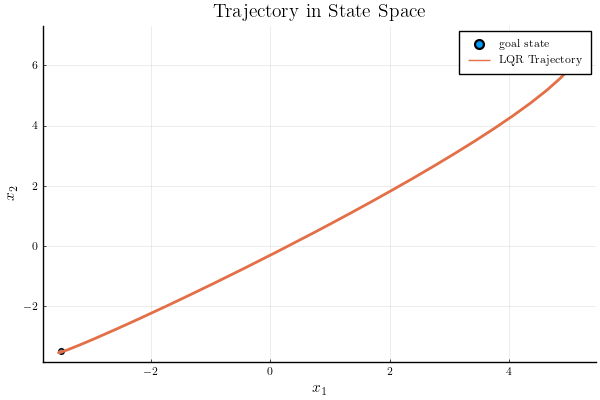

Test Summary:             | Pass  Total  Time
Why LQR is great reason 2 |    3      3  0.5s


In [35]:
@testset "Why LQR is great reason 2" begin

    # problem stuff
    dt = 0.1
    tf = 20.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)
    x0 = [5, 7, 2, -1.4] # initial condition 
    Q = diagm(ones(nx))
    R = diagm(ones(nu))
    Qf = 10 * Q

    P, K = fhlqr(A, B, Q, R, Qf, N)

    # specify a goal state with 0 velocity within a 5m radius of 0 
    xgoal = [-3.5, -3.5, 0, 0]
    @test norm(xgoal[1:2]) < 5
    @test norm(xgoal[3:4]) < 1e-13 # ensure 0 velocity

    Xsim_lqr = [zeros(nx) for i = 1:N]
    Xsim_lqr[1] = 1 * x0

    for i = 1:N-1
        u_lqr = -K[i] * (Xsim_lqr[i] - xgoal)
        Xsim_lqr[i+1] = A * Xsim_lqr[i] + B * u_lqr
    end

    @test norm(Xsim_lqr[end][1:2] - xgoal[1:2]) < 0.1

    # ------------------------plotting--------------------------
    Xm = mat_from_vec(Xsim_lqr)
    plot(xgoal[1:1], xgoal[2:2], seriestype = :scatter, label = "goal state")
    display(
        plot!(
            Xm[1, :],
            Xm[2, :],
            title = "Trajectory in State Space",
            ylabel = L"x_2",
            xlabel = L"x_1",
            lw = 2,
            label = "LQR Trajectory",
        ),
    )
    PyPlot.close()

end;

## Part D: Infinite-horizon LQR 
Up until this point, we have looked at finite-horizon LQR which only considers a finite number of timesteps in our trajectory.  When this problem is solved with a Ricatti recursion, there is a new feedback gain matrix $K_k$ for each timestep. As the length of the trajectory increases, the first feedback gain matrix $K_1$ will begin to converge on what we call the "infinite-horizon LQR gain".  This is the value that $K_1$ converges to as $N \rightarrow \infty$.

Below, we will plot the values of $P$ and $K$ throughout the horizon and observe this convergence. 

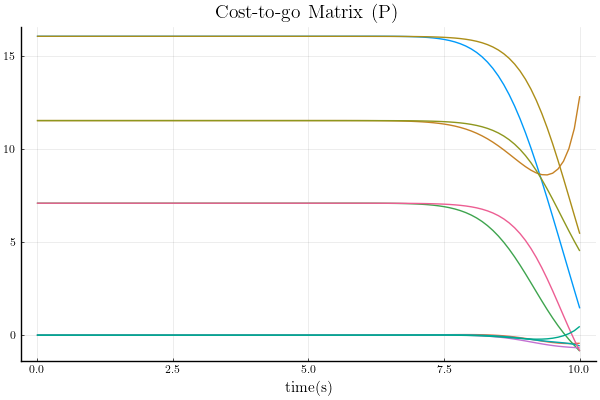

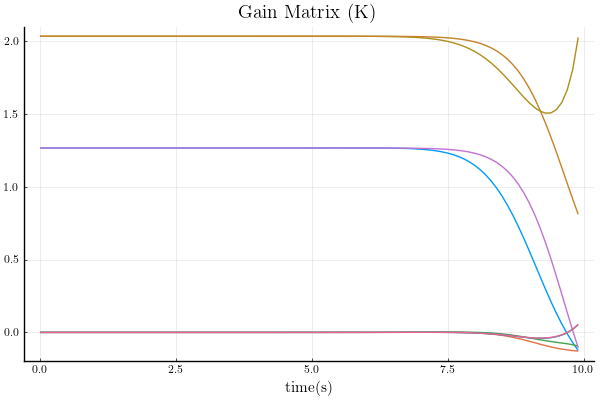

Test Summary:         | Pass  Total  Time
P and K time analysis |    2      2  3.4s


In [36]:
# half vectorization of a matrix 
function vech(A)
    return A[tril(trues(size(A)))]
end
@testset "P and K time analysis" begin

    # problem stuff
    dt = 0.1
    tf = 10.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)

    # we're just going to modify the system a little bit 
    # so the following graphs are still interesting
    Q = diagm(ones(nx))
    R = 0.5 * diagm(ones(nu))
    Qf = randn(nx, nx)
    Qf = Qf' * Qf + I

    P, K = fhlqr(A, B, Q, R, Qf, N)

    Pm = hcat(vech.(P)...)
    Km = hcat(vec.(K)...)

    # make sure these things converged 
    @test 1e-13 < norm(P[1] - P[2]) < 1e-3
    @test 1e-13 < norm(K[1] - K[2]) < 1e-3

    display(
        plot(t_vec, Pm', label = "", title = "Cost-to-go Matrix (P)", xlabel = "time(s)"),
    )
    display(
        plot(
            t_vec[1:end-1],
            Km',
            label = "",
            title = "Gain Matrix (K)",
            xlabel = "time(s)",
        ),
    )
    PyPlot.close()

end;

infinite horizon LQR function: do a Ricatti recursion until the cost to go matrix $P$ converges:

$$ \|P_k - P_{k+1}\| \leq \text{tol}$$

And return the steady state $P$ and $K$. 

In [38]:
# infinite horizon LQR function:
# do the ricatti recursion until the cost to go matrix 
# P converges to a steady value |P_k - P_{k+1}| ≤ tol 
function ihlqr(
    A::Matrix,       # vector of A matrices 
    B::Matrix,       # vector of B matrices
    Q::Matrix,       # cost matrix Q 
    R::Matrix;       # cost matrix R 
    max_iter = 1000, # max iterations for Ricatti 
    tol = 1e-5,       # convergence tolerance
)::Tuple{Matrix,Matrix} # return two matrices 

    # get size of x and u from B 
    nx, nu = size(B)

    # initialize S with Q
    P = deepcopy(Q)

    # Ricatti 
    for ricatti_iter = 1:max_iter
        K = (R + B' * P * B) \ (B' * P * A)
        Pnew = Q + K' * R * K + (A - B * K)'P * (A - B * K)
        if norm(P - Pnew, Inf) < tol
            return Pnew, K
        end

        # update P 
        P = 1 * Pnew
    end
    error("ihlqr did not converge")
end;
@testset "ihlqr test" begin
    # problem stuff
    dt = 0.1
    A, B = double_integrator_AB(dt)
    nx, nu = size(B)

    # we're just going to modify the system a little bit 
    # so the following graphs are still interesting

    Q = diagm(ones(nx))
    R = 0.5 * diagm(ones(nu))
    P, K = ihlqr(A, B, Q, R)

    # check this S is in fact a solution to the Ricatti equation
    @test typeof(P) == Matrix{Float64}
    @test typeof(K) == Matrix{Float64}
    @test 1e-13 < norm(Q + K' * R * K + (A - B * K)'P * (A - B * K) - P) < 1e-3

end;

Test Summary: | Pass  Total  Time
ihlqr test    |    3      3  0.0s
